### Import Libarries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [37]:
df=pd.read_csv("Salary_Data.csv")
print("Data Set Load Sucessfuly")

Data Set Load Sucessfuly


In [38]:
df.shape

(6704, 6)

In [39]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [41]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [42]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

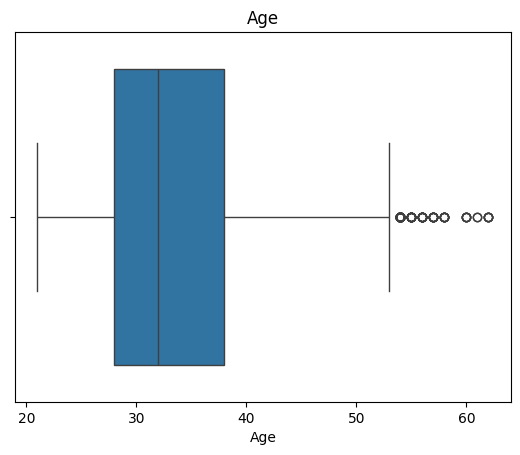

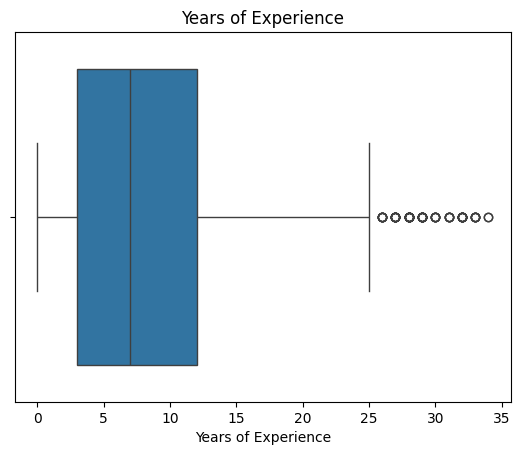

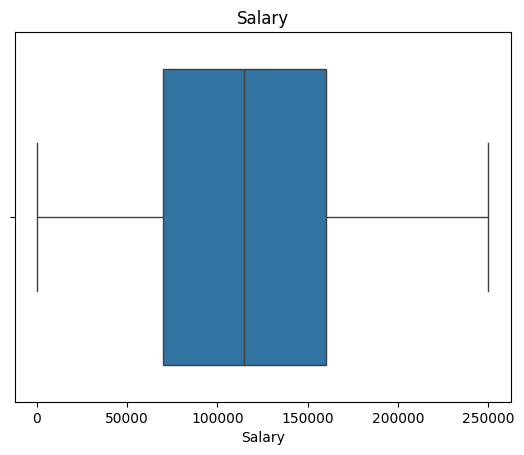

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [44]:
df.duplicated().sum()

np.int64(4912)

In [45]:
# Duplicates remove karna
df.drop_duplicates(inplace=True)

print("Remaining Duplicate Rows:", df.duplicated().sum())
print("New Shape of Dataset:", df.shape)

Remaining Duplicate Rows: 0
New Shape of Dataset: (1792, 6)


In [46]:

df.isnull().sum()

Age                    1
Gender                 1
Education Level        2
Job Title              1
Years of Experience    2
Salary                 4
dtype: int64

In [47]:
df.dropna(subset=['Salary'], inplace=True)

In [48]:

df.isnull().sum()

Age                    0
Gender                 0
Education Level        1
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [49]:
df['Education Level']=df['Education Level'].fillna(df['Education Level'].mode()[0])

# Final null check
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

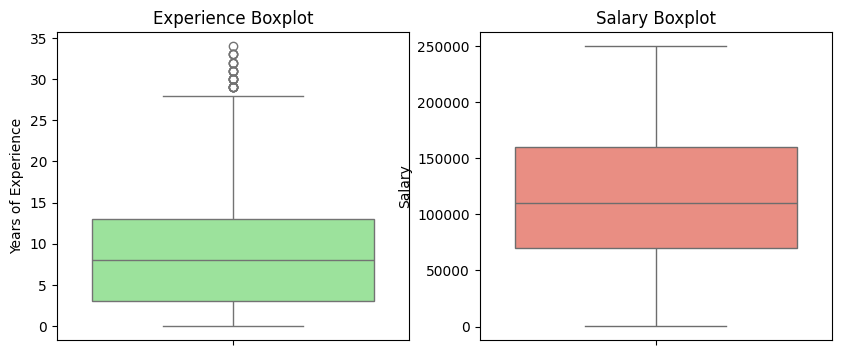

Lower Boundary: -65000.0
Upper Boundary: 295000.0
Number of Salary Outliers: 0


In [50]:
# 1. Boxplot se visual test karein
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Years of Experience'], color='lightgreen')
plt.title('Experience Boxplot')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Salary'], color='salmon')
plt.title('Salary Boxplot')
plt.show()

# 2. Mathematical IQR calculation for Salary
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Boundary:", lower_limit)
print("Upper Boundary:", upper_limit)

# Outliers check karein
outliers = df[(df['Salary'] < lower_limit) | (df['Salary'] > upper_limit)]
print("Number of Salary Outliers:", len(outliers))

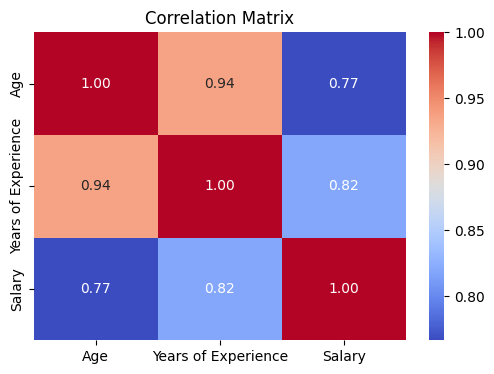

In [51]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Age', 'Years of Experience', 'Salary']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [52]:
# Education Level ki ranking define karna
education_map = {
    'High School': 0,
    "Bachelor's": 1,
    "Master's": 2,
    'PhD': 3
}

# Column par map apply karna
df['Education_Encoded'] = df['Education Level'].map(education_map)

# Check karne ke liye top rows dekhein
df[['Education Level', 'Education_Encoded']].head(10)

,Education Level,Education_Encoded
0,Bachelor's,1.0
1,Master's,2.0
2,PhD,3.0
3,Bachelor's,1.0
4,Master's,2.0
5,Bachelor's,1.0
6,Master's,2.0
7,Bachelor's,1.0
8,Bachelor's,1.0
9,PhD,3.0


In [53]:

df = pd.get_dummies(df, columns=['Gender'], drop_first=True, dtype=int)

In [54]:
df['Job Title'].nunique()

192

In [55]:
top_10_jobs = df['Job Title'].value_counts().head(10).index

df['Job Title Grouped'] = df['Job Title'].apply(lambda x: x if x in top_10_jobs else 'Other')
print("New Unique Job Categories:", df['Job Title Grouped'].nunique())
print("\nValue Counts:\n", df['Job Title Grouped'].value_counts())

New Unique Job Categories: 11

Value Counts:
 Job Title Grouped
Other                        930
Software Engineer Manager    127
Full Stack Engineer          122
Senior Software Engineer      96
Senior Project Engineer       95
Back end Developer            81
Data Scientist                80
Software Engineer             78
Front end Developer           71
Marketing Manager             55
Product Manager               53
Name: count, dtype: int64


In [56]:
# 1. Education Level Mapping
education_map = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
if 'Education Level' in df.columns:
    df['Education_Encoded'] = df['Education Level'].map(education_map)

# 2. Existing columns check karke encode karna
cols_to_encode = [col for col in ['Gender', 'Job Title Grouped'] if col in df.columns]
if cols_to_encode:
    df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)
else:
    df_encoded = df.copy()

# 3. Text columns drop karna (agar maujood hon)
cols_to_drop = [col for col in ['Education Level', 'Job Title'] if col in df_encoded.columns]
df_encoded.drop(columns=cols_to_drop, inplace=True)

# 4. Final Verification
print("Columns ready for ML:", df_encoded.columns.tolist())

Columns ready for ML: ['Age', 'Years of Experience', 'Salary', 'Education_Encoded', 'Gender_Male', 'Gender_Other', 'Job Title Grouped_Data Scientist', 'Job Title Grouped_Front end Developer', 'Job Title Grouped_Full Stack Engineer', 'Job Title Grouped_Marketing Manager', 'Job Title Grouped_Other', 'Job Title Grouped_Product Manager', 'Job Title Grouped_Senior Project Engineer', 'Job Title Grouped_Senior Software Engineer', 'Job Title Grouped_Software Engineer', 'Job Title Grouped_Software Engineer Manager']


In [57]:
df_encoded.dropna(inplace=True)

In [58]:
X = df_encoded.drop(columns=['Salary'])
y = df_encoded['Salary']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
model=LinearRegression()
model.fit(X_train ,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ 222.69, 4175.74, 17369.13,..., -8031.1 , 53448.16,-20249.57]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['Age','Years of Experience','Education_Encoded',..., 'Job Title Grouped_Senior Software Engineer', 'Job Title Grouped_Software Engineer', 'Job Title Grouped_Software Engineer Manager']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.363e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)


In [61]:
y_pred = model.predict(X_test)

In [62]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score (Accuracy): {r2:.4f}")
print(f"RMSE (Average Error): ${rmse:,.2f}")

R² Score (Accuracy): 0.8464
RMSE (Average Error): $23,460.94


In [63]:
# Unseen record par salary predict karna
sample_data = X_test.iloc[[0]]  
actual_salary = y_test.iloc[0]  # Real salary

predicted_salary = model.predict(sample_data)[0]

print(f"Actual Salary:    ${actual_salary:,.2f}")
print(f"Predicted Salary: ${predicted_salary:,.2f}")
print(f"Difference:       ${abs(actual_salary - predicted_salary):,.2f}")

Actual Salary:    $151,310.00
Predicted Salary: $165,117.86
Difference:       $13,807.86


In [64]:
# 1. Scaler initialize karna
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [65]:
# Gradient Boosting Model
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
gb_pred = gb_model.predict(X_test)

# Metrics
gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print("--- Gradient Boosting Results ---")
print(f"R² Score: {gb_r2:.4f}")
print(f"RMSE Error: ${gb_rmse:,.2f}")

--- Gradient Boosting Results ---
R² Score: 0.8948
RMSE Error: $19,417.51


In [66]:
# SVM Model 
svm_model = SVR(kernel='rbf', C=10000)
svm_model.fit(X_train_scaled, y_train)

# Predictions
svm_pred = svm_model.predict(X_test_scaled)

# Evaluation
svm_r2 = r2_score(y_test, svm_pred)
svm_rmse = np.sqrt(mean_squared_error(y_test, svm_pred))

print("\n--- SVM (SVR) Results ---")
print(f"R² Score: {svm_r2:.4f}")
print(f"RMSE Error: ${svm_rmse:,.2f}")


--- SVM (SVR) Results ---
R² Score: 0.8181
RMSE Error: $25,533.32


--- Feature Importance List ---
                                    Feature  Importance
                        Years of Experience    0.666319
                    Job Title Grouped_Other    0.118259
                                        Age    0.107850
                          Education_Encoded    0.067712
        Job Title Grouped_Marketing Manager    0.013482
           Job Title Grouped_Data Scientist    0.008341
        Job Title Grouped_Software Engineer    0.006869
          Job Title Grouped_Product Manager    0.004939
      Job Title Grouped_Full Stack Engineer    0.002300
  Job Title Grouped_Senior Project Engineer    0.001546
                                Gender_Male    0.000966
Job Title Grouped_Software Engineer Manager    0.000654
 Job Title Grouped_Senior Software Engineer    0.000637
                               Gender_Other    0.000112
      Job Title Grouped_Front end Developer    0.000016


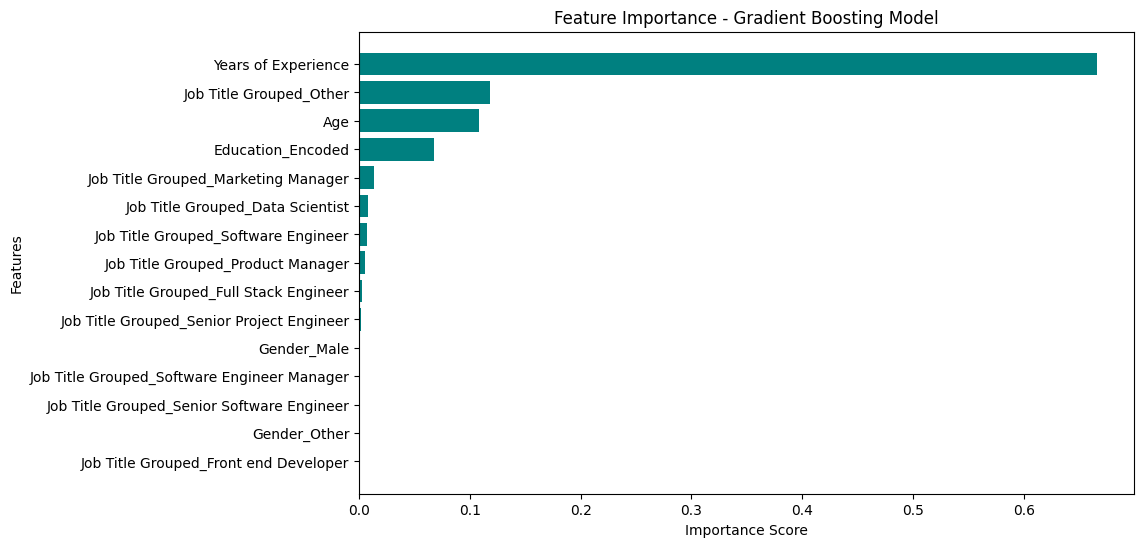

In [67]:
# 1. Feature importances array extract karna
importances = gb_model.feature_importances_
feature_names = X.columns

# 2. DataFrame bana kar arrange karna
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Text output print karna
print("--- Feature Importance List ---")
print(importance_df.to_string(index=False))

# 4. Bar Plot visuals ke liye
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance - Gradient Boosting Model')
plt.gca().invert_yaxis()  # Sabse important top par aye
plt.show()

In [68]:
import joblib
joblib.dump(gb_model, 'salary_gb_model.pkl')

['salary_gb_model.pkl']

In [69]:
import joblib

# Model aur exact column names ek saath save karein
model_data = {
    'model': gb_model,
    'features': list(X_train.columns)
}

joblib.dump(model_data, 'salary_gb_model.pkl')
print("Model and features saved successfully!")

Model and features saved successfully!
